# Customer Segmentation — Clustering Notebook

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Clustering with Standard Scaler](#2-clustering-with-standard-scaler)
   - 2.1 K-Means
   - 2.2 Mean Shift
   - 2.3 Hierarchical Clustering
   - 2.4 DBSCAN
   - 2.5 SOM (Self-Organizing Map)
3. [Clustering with Robust Scaler](#3-clustering-with-robust-scaler)
   - 3.1 K-Means
   - 3.2 Mean Shift
   - 3.3 Hierarchical Clustering
   - 3.4 DBSCAN
   - 3.5 SOM (Self-Organizing Map)
4. [Clustering with MinMax Scaler](#4-clustering-with-minmax-scaler)
   - 4.1 K-Means
   - 4.2 Mean Shift
   - 4.3 Hierarchical Clustering
   - 4.4 DBSCAN
   - 4.5 SOM (Self-Organizing Map)
5. [Model Comparison](#5-model-comparison)
   - 5.1 Silhouette Comparison

# 1. Setup & Data Loading

In [1]:
# Import necessary libraries for data processing and visualization
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MeanShift
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Import all clustering algorithms and helper functions from Clustering.py
import importlib
import Clustering
importlib.reload(Clustering)
from Clustering import (
    find_optimal_k, fit_kmeans, fit_hierarchical, find_optimal_eps, 
    fit_dbscan, compare_models, _initialize_som_weights, _find_bmu, 
    _som_learning_rate, _som_radius, plot_som_u_matrix, fit_som, 
    get_som_cluster_labels, assign_som_clusters, fit_meanshift, plot_umap, plot_tsne
)

# Import preprocessing functions from Preprocessing.py
from Preprocessing import (
    preprocess_data_standardscaler, preprocess_data_robustscaler, 
    preprocess_data_minmaxscaler, cluster_analysis
)

In [2]:
df = pd.read_csv('customer_info_engineered.csv')

# 1. Criar um DataFrame novo para guardar a junção
#df2 = pd.DataFrame(index=df.index)

# 2. Calcular a tua métrica (com os valores reais)
df['promo_hunter_score'] = df['percentage_of_products_bought_promotion'] * df['distinct_stores_visited']

# 3. Juntar as outras duas colunas vindas diretamente do df original (sem escala)
df['total_lifetime_spend'] = df['total_lifetime_spend']
df['percentage_of_products_bought_promotion'] = df['percentage_of_products_bought_promotion']

# Visualizar o resultado final das colunas juntas
print(df.head())

           customer_name  kids_home  teens_home  number_complaints  \
0  Bsc. Crystal Kitchens        1.0         1.0                1.0   
1     Bsc. Glenda Bauman        1.0         0.0                0.0   
2  Msc. Antonio Campbell        0.0         0.0                NaN   
3           John Kelling        0.0         0.0                2.0   
4        Arthur Dematteo        0.0         0.0                3.0   

   distinct_stores_visited  lifetime_spend_groceries  \
0                      3.0                   11731.0   
1                      2.0                   13694.0   
2                      2.0                   12407.0   
3                      1.0                    7493.0   
4                      1.0                    9187.0   

   lifetime_spend_electronics  typical_hour  lifetime_spend_vegetables  \
0                      4553.0           NaN                      373.0   
1                       963.0           NaN                     2012.0   
2                   

In [6]:
# Define the selected subset of features for clustering (lifestyle & spend metrics)
df = df[[
    'promo_hunter_score',
    'percentage_of_products_bought_promotion',
    'total_lifetime_spend',
    'number_complaints'
]]
print(df)


       promo_hunter_score  percentage_of_products_bought_promotion  \
0                1.894796                                 0.631599   
1                0.299780                                 0.149890   
2                0.138251                                 0.069126   
3                0.253609                                 0.253609   
4                0.186569                                 0.186569   
...                   ...                                      ...   
33033            0.261352                                 0.261352   
33034            0.143479                                 0.143479   
33035            0.727669                                 0.181917   
33036            4.843552                                 0.807259   
33037            0.252563                                 0.252563   

       total_lifetime_spend  number_complaints  
0                   18590.0                1.0  
1                   20233.0                0.0  
2           

In [7]:
# Preprocess and scale the dataset using Standard, Robust, and MinMax scalers
df_processed_st = preprocess_data_standardscaler(df)
df_processed_rb = preprocess_data_robustscaler(df)
df_processed_mm = preprocess_data_minmaxscaler(df)

/Users/joanaanmartins/Desktop/NOVAIMS/Course Assignment - Customer Segmentation-20260417/Preprocessing.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[clustering_cols] = imputer.fit_transform(df[clustering_cols])
/Users/joanaanmartins/Desktop/NOVAIMS/Course Assignment - Customer Segmentation-20260417/Preprocessing.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.log1p(df[col])
/Users/joanaanmartins/Desktop/NOVAIMS/Course Assignment - Customer Segmentation-20260417/Preprocessing.py:3

In [8]:
# Run baseline profile analysis on the unscaled customer dataset
df_cluster_anaylsis = cluster_analysis(df)

/Users/joanaanmartins/Desktop/NOVAIMS/Course Assignment - Customer Segmentation-20260417/Preprocessing.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[num_cols] = imputer.fit_transform(df[num_cols])
/Users/joanaanmartins/Desktop/NOVAIMS/Course Assignment - Customer Segmentation-20260417/Preprocessing.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.log1p(df[col])


# 2. Clustering with Standard Scaler

## 2.1 K-Means

k=2 | Inertia: 1391.93 | Silhouette: 0.5573
k=3 | Inertia: 1024.69 | Silhouette: 0.4031
k=4 | Inertia: 831.70 | Silhouette: 0.3953
k=5 | Inertia: 698.28 | Silhouette: 0.3364
k=6 | Inertia: 616.88 | Silhouette: 0.3403
k=7 | Inertia: 549.68 | Silhouette: 0.3383
k=8 | Inertia: 498.23 | Silhouette: 0.3418
k=9 | Inertia: 454.75 | Silhouette: 0.3320
k=10 | Inertia: 413.04 | Silhouette: 0.3451


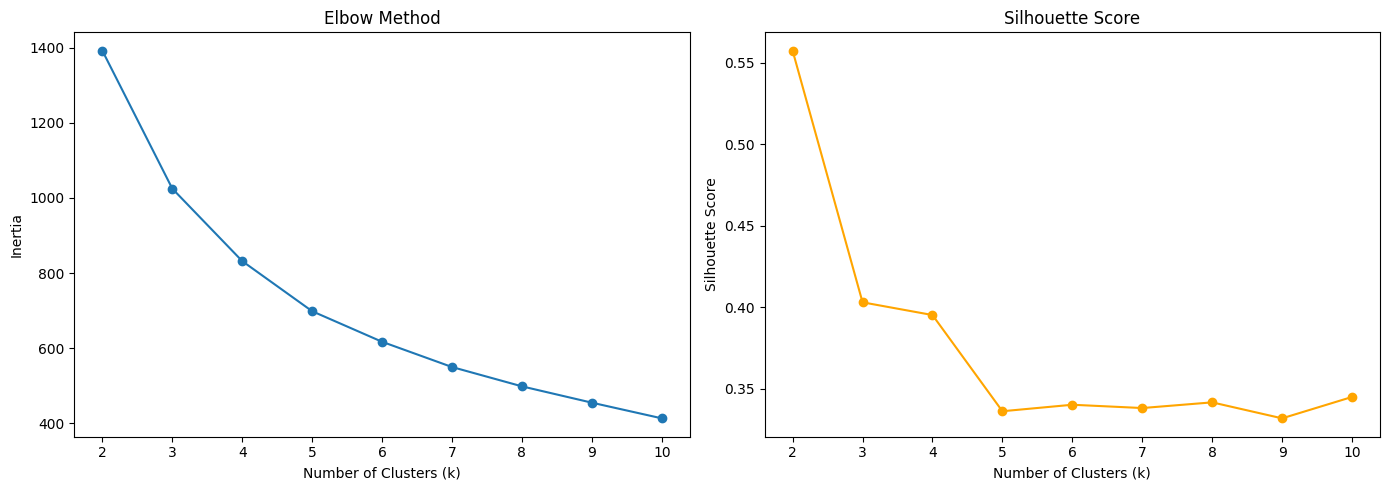

In [24]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_processed_st)

In [25]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_st = fit_kmeans(df_processed_st, 4)
print(kmeans_profile_st)

Silhouette Score: 0.3953
Cluster sizes:
0    16833
1     4887
2     7415
3     3903
Name: count, dtype: int64
                                         cluster_0  cluster_1  cluster_2  \
promo_hunter_score                        0.052136   0.362112   0.190377   
percentage_of_products_bought_promotion   0.167588   0.849495   0.473136   
total_lifetime_spend                      0.503976   0.498631   0.503703   
number_complaints                         0.077447   0.148476   0.135243   

                                         cluster_3  
promo_hunter_score                        0.065434  
percentage_of_products_bought_promotion   0.228508  
total_lifetime_spend                      0.506962  
number_complaints                         0.348750  


In [26]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_st = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans_st = kmeans_opt_st.fit_predict(df_processed_st)

/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


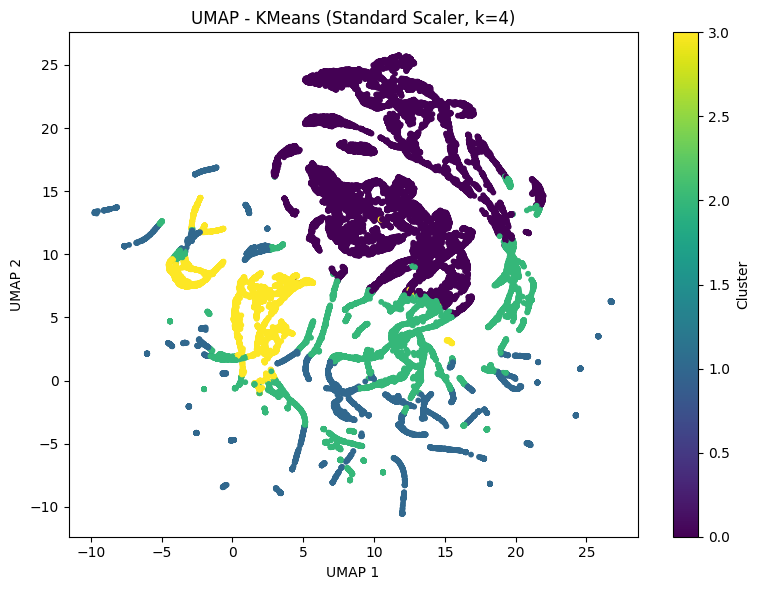

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [27]:
# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_kmeans_st, title="UMAP - KMeans (Standard Scaler, k=4)")

## 2.2 Mean Shift

In [28]:
# Fit Mean Shift clustering to automatically determine the number of clusters
mean_shift_st = MeanShift(bin_seeding=True)
labels_ms_st = mean_shift_st.fit_predict(df_processed_st)
print("Standard Scaler MeanShift cluster count:", len(np.unique(labels_ms_st)))
if len(np.unique(labels_ms_st)) > 1:
    print(f"Standard Scaler MeanShift silhouette: {silhouette_score(df_processed_st, labels_ms_st):.4f}")
else:
    print("Standard Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_st).value_counts().sort_index())

Standard Scaler MeanShift cluster count: 2
Standard Scaler MeanShift silhouette: 0.5640
0    27224
1     5814
Name: count, dtype: int64


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


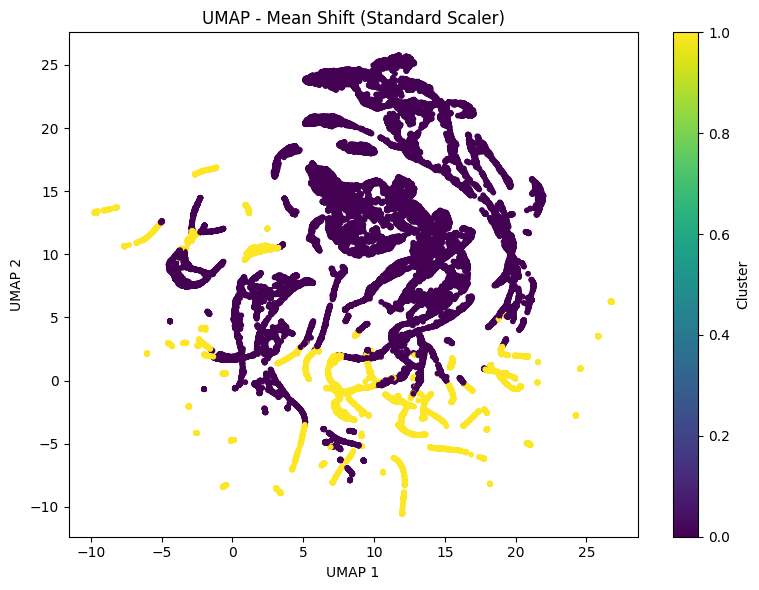

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [29]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_ms_st, title="UMAP - Mean Shift (Standard Scaler)")

## 2.3 Hierarchical Clustering

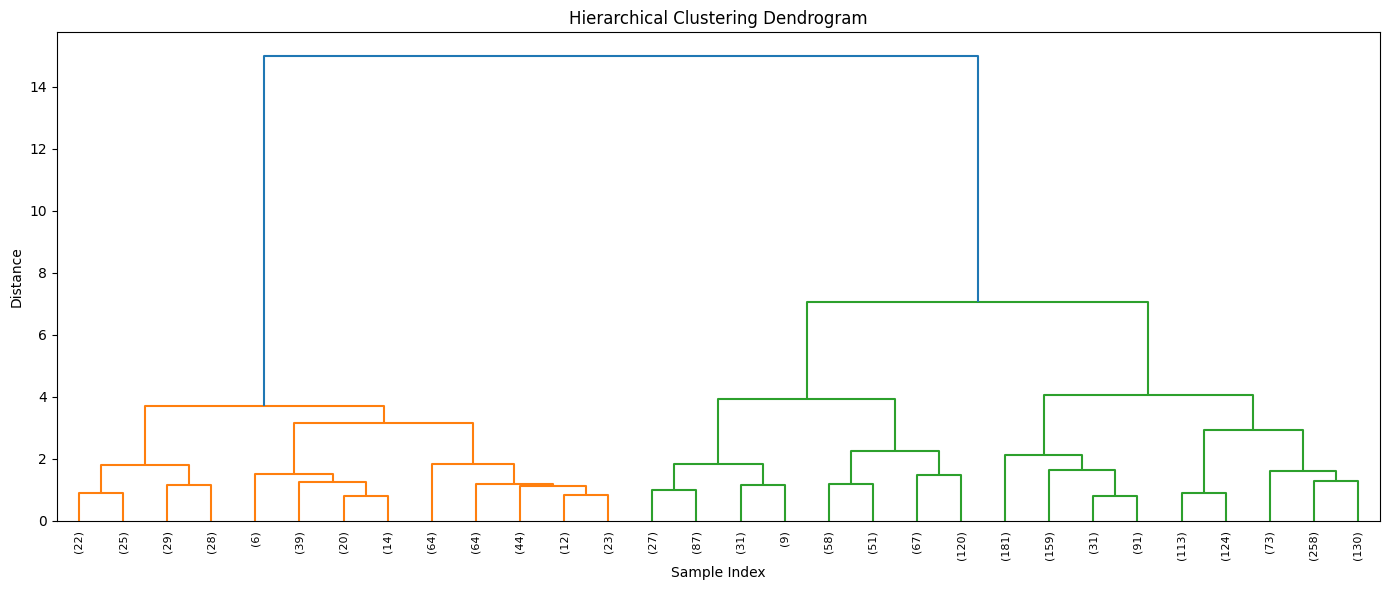

Silhouette Score: 0.2758
Cluster sizes:
0    10961
1     5256
2     5146
3     2388
4     9287
Name: count, dtype: int64


In [30]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_st, labels_hierarchical_st = fit_hierarchical(df_processed_st, 5, method='ward')

/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


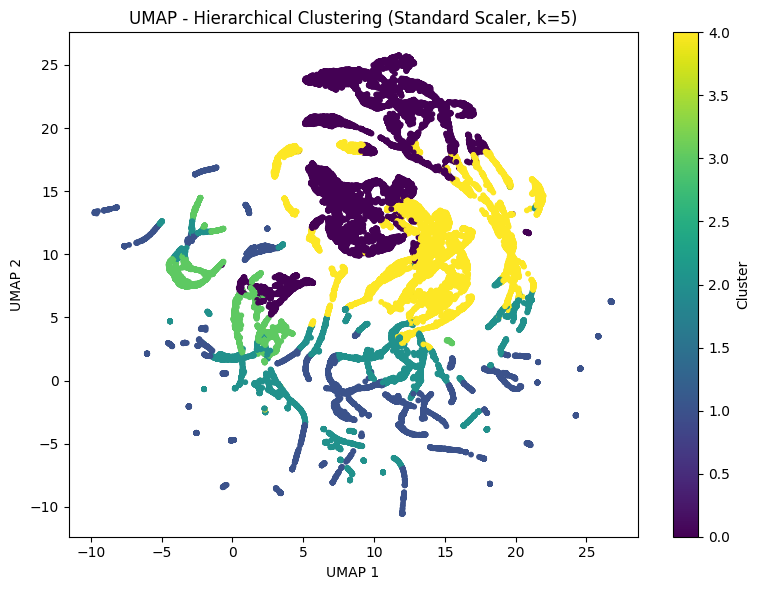

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [31]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_hierarchical_st, title="UMAP - Hierarchical Clustering (Standard Scaler, k=5)")

## 2.4 DBSCAN

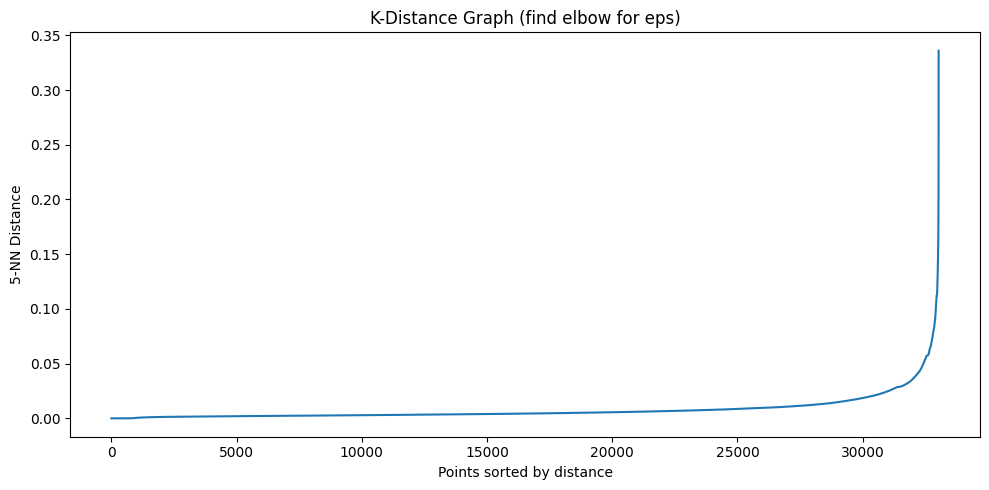

In [32]:
# Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_processed_st, n_neighbors=5)

In [33]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_processed_st, 2.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


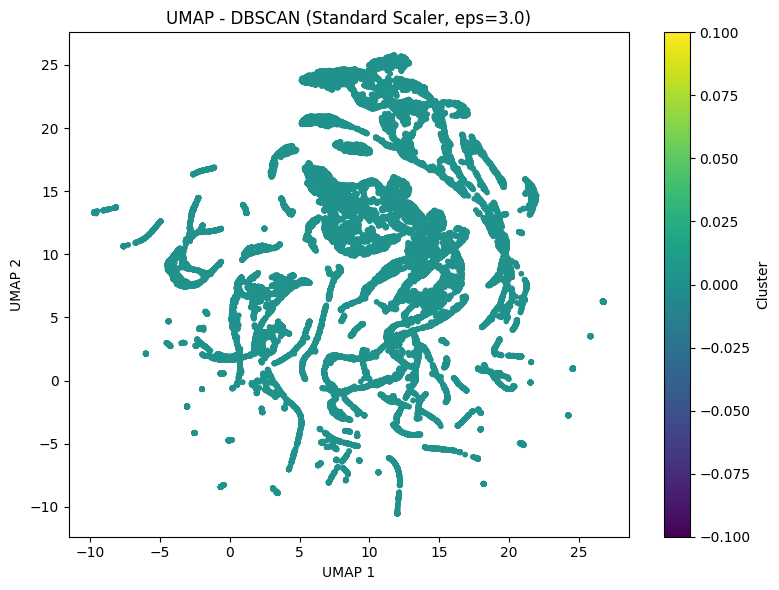

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [34]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_st, labels_dbscan_st = fit_dbscan(df_processed_st, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_st, labels_dbscan_st, title="UMAP - DBSCAN (Standard Scaler, eps=3.0)")

In [35]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_processed_st, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=3.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


## 2.5 Self-Organizing Map (SOM)

In [36]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_st = fit_som(df_processed_st, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

Trained SOM with map shape (10, 10) and 1000 iterations.
Unique BMU clusters: 100


In [37]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_st = get_som_cluster_labels(som_result_st['weights'], n_clusters=5, random_state=42)
print(neuron_labels_st)

[[3 3 2 2 2 2 1 1 1 1]
 [3 3 3 2 2 2 1 1 1 1]
 [3 3 3 3 2 2 2 1 1 1]
 [3 3 3 3 4 2 2 2 1 1]
 [3 3 3 4 4 4 2 2 2 2]
 [0 0 0 0 4 4 4 2 2 2]
 [0 0 0 0 4 4 4 4 4 4]
 [0 0 0 0 0 0 4 4 4 4]
 [0 0 0 0 0 0 0 4 4 4]
 [0 0 0 0 0 0 0 4 4 4]]


In [38]:
# Assign each data sample to a SOM neuron cluster label
labels_som_st, neuron_labels_st = assign_som_clusters(som_result_st['weights'], df_processed_st, n_clusters=5, random_state=42)
print((labels_som_st, neuron_labels_st))

(array([2, 0, 0, ..., 0, 1, 0], shape=(33038,), dtype=int32), array([[3, 3, 2, 2, 2, 2, 1, 1, 1, 1],
       [3, 3, 3, 2, 2, 2, 1, 1, 1, 1],
       [3, 3, 3, 3, 2, 2, 2, 1, 1, 1],
       [3, 3, 3, 3, 4, 2, 2, 2, 1, 1],
       [3, 3, 3, 4, 4, 4, 2, 2, 2, 2],
       [0, 0, 0, 0, 4, 4, 4, 2, 2, 2],
       [0, 0, 0, 0, 4, 4, 4, 4, 4, 4],
       [0, 0, 0, 0, 0, 0, 4, 4, 4, 4],
       [0, 0, 0, 0, 0, 0, 0, 4, 4, 4],
       [0, 0, 0, 0, 0, 0, 0, 4, 4, 4]], dtype=int32))


## 2.6 T-SNE

A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...
--- A gerar projeções t-SNE para comparação de modelos ---


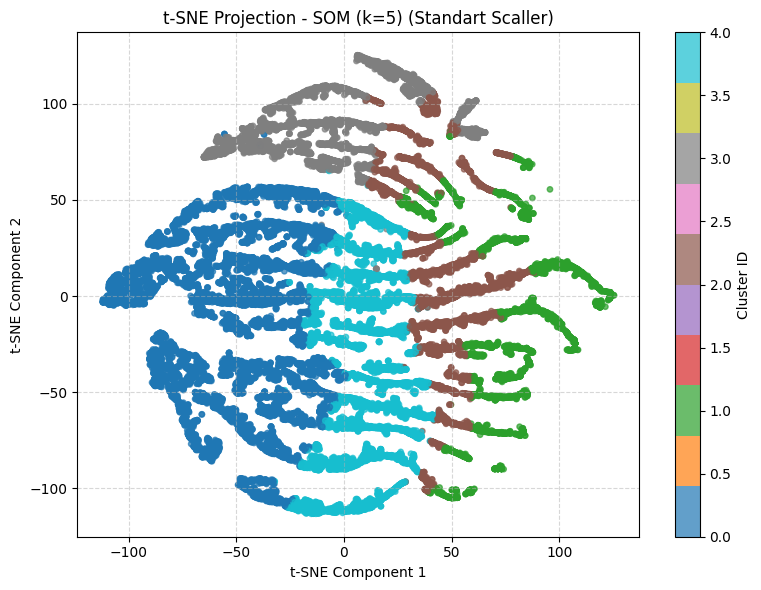

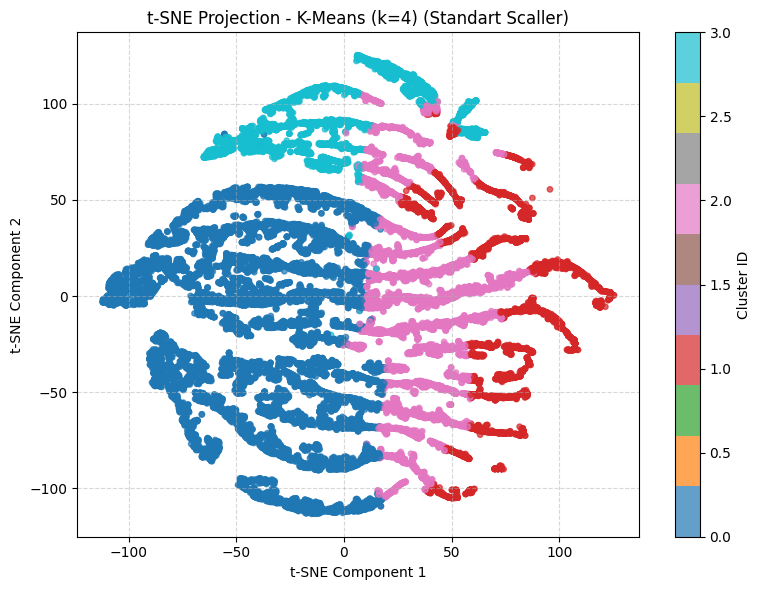

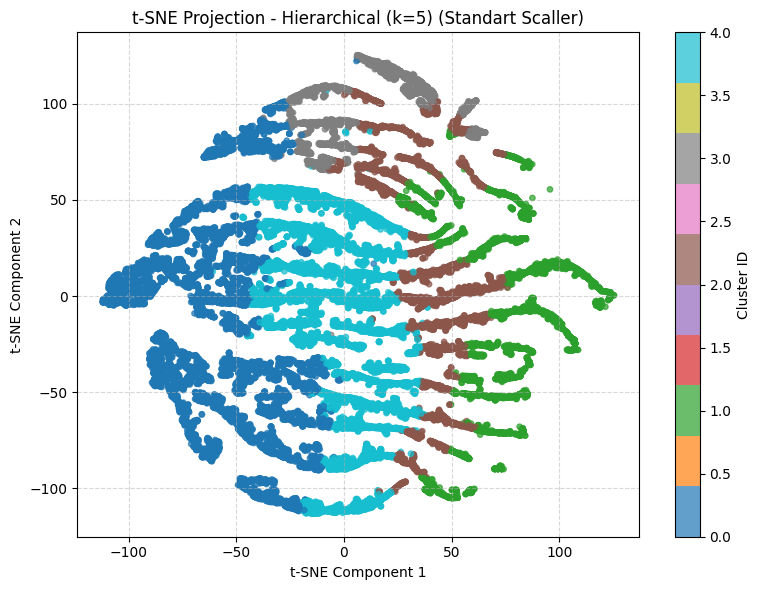

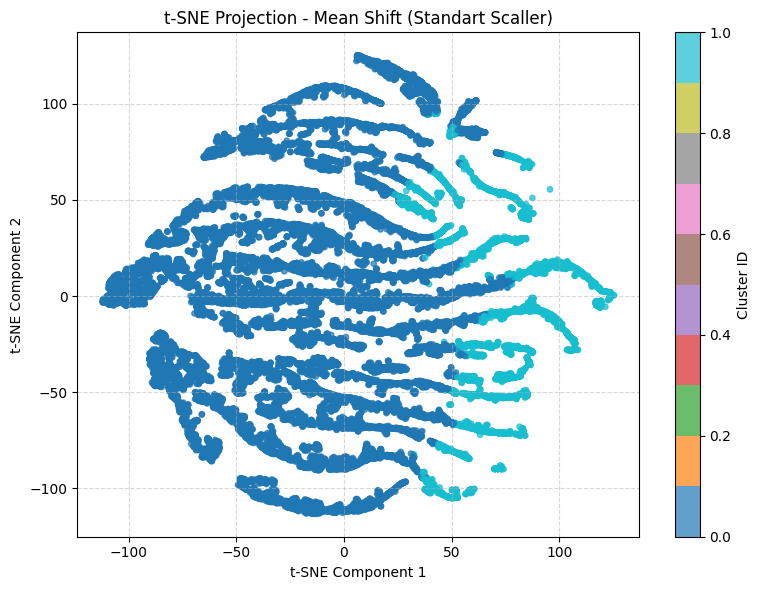

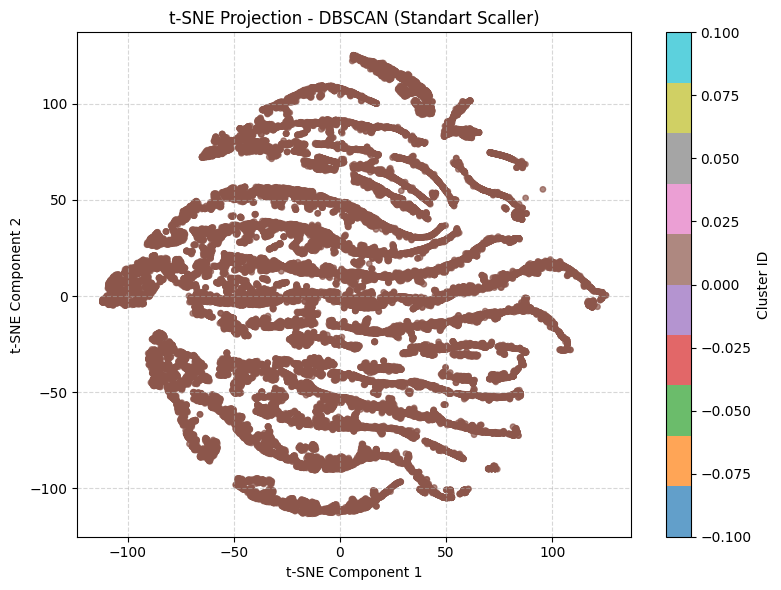

In [81]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. PASSO ÚNICO: Calcular as coordenadas t-SNE uma única vez para o teu dataset
# (Isto é o que demora tempo, por isso fazemos fora do loop)
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca', max_iter=1000)

print("A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...")
X_tsne = tsne.fit_transform(df_processed_st)


# 2. DEFINIR O DICIONÁRIO: Junta aqui as variáveis de labels de todos os teus modelos
# Certifica-te de que já correstes as células que criam estas variáveis de labels!
labels_todos_modelos = {
    'SOM (k=5)': labels_som_st,
    'K-Means (k=4)': labels_kmeans_st,          # Descomenta se tiveres esta variável
    'Hierarchical (k=5)': labels_hierarchical_st, # Descomenta se tiveres esta variável
    'Mean Shift': labels_ms_st,
    'DBSCAN': labels_dbscan_st                    # Descomenta se tiveres esta variável
}


# 3. O LOOP: Desenhar automaticamente um gráfico t-SNE para cada modelo
print("--- A gerar projeções t-SNE para comparação de modelos ---")

for nome_modelo, labels_modelo in labels_todos_modelos.items():
    
    plt.figure(figsize=(8, 6))
    
    # Criar o gráfico usando as mesmas coordenadas X_tsne, mas mudando as cores (c=labels_modelo)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_modelo, cmap='tab10', s=15, alpha=0.7)
    
    # Configurações estéticas do gráfico
    plt.colorbar(scatter, label='Cluster ID')
    plt.title(f"t-SNE Projection - {nome_modelo} (Standart Scaller)")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# 3. Clustering with Robust Scaler

## 3.1 K-Means

k=2 | Inertia: 1391.93 | Silhouette: 0.5573
k=3 | Inertia: 1024.69 | Silhouette: 0.4031
k=4 | Inertia: 831.70 | Silhouette: 0.3953
k=5 | Inertia: 698.28 | Silhouette: 0.3364
k=6 | Inertia: 616.88 | Silhouette: 0.3403
k=7 | Inertia: 549.68 | Silhouette: 0.3383
k=8 | Inertia: 498.23 | Silhouette: 0.3418
k=9 | Inertia: 454.75 | Silhouette: 0.3320
k=10 | Inertia: 413.04 | Silhouette: 0.3451


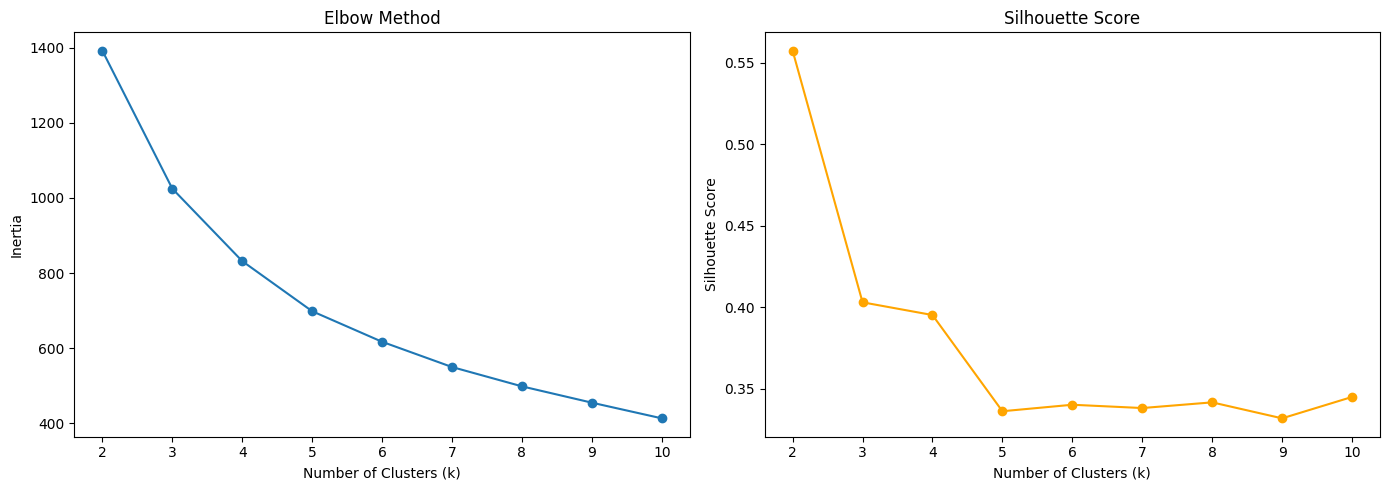

In [40]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_processed_rb)

In [41]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_rb = fit_kmeans(df_processed_rb, 4)
print(kmeans_profile_rb)

Silhouette Score: 0.3953
Cluster sizes:
0    16833
1     4887
2     7415
3     3903
Name: count, dtype: int64
                                         cluster_0  cluster_1  cluster_2  \
promo_hunter_score                        0.052136   0.362112   0.190377   
percentage_of_products_bought_promotion   0.167588   0.849495   0.473136   
total_lifetime_spend                      0.503976   0.498631   0.503703   
number_complaints                         0.077447   0.148476   0.135243   

                                         cluster_3  
promo_hunter_score                        0.065434  
percentage_of_products_bought_promotion   0.228508  
total_lifetime_spend                      0.506962  
number_complaints                         0.348750  


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


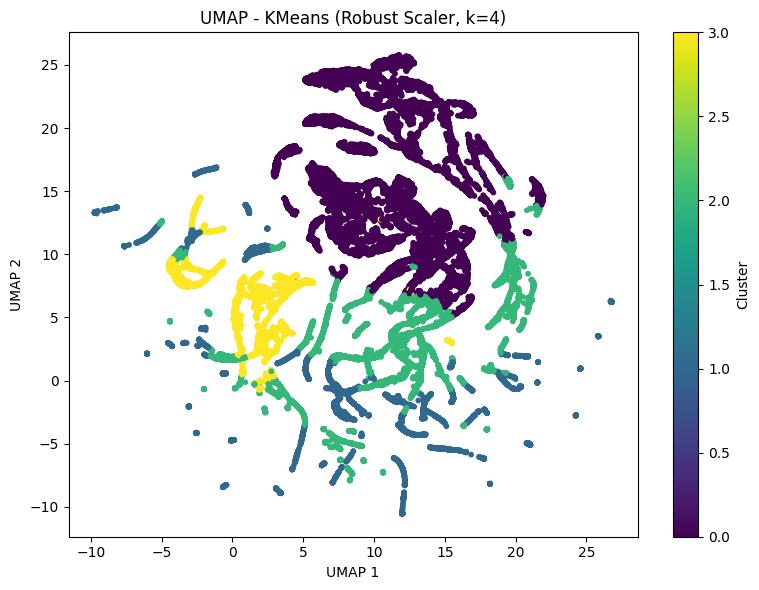

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [42]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_rb = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans_rb = kmeans_opt_rb.fit_predict(df_processed_rb)

# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_kmeans_rb, title="UMAP - KMeans (Robust Scaler, k=4)")

## 3.2 Mean Shift

In [43]:
# Fit Mean Shift clustering to automatically determine the number of clusters
mean_shift_rb = MeanShift(bin_seeding=True)
labels_ms_rb = mean_shift_rb.fit_predict(df_processed_rb)
print("Robust Scaler MeanShift cluster count:", len(np.unique(labels_ms_rb)))
if len(np.unique(labels_ms_rb)) > 1:
    print(f"Robust Scaler MeanShift silhouette: {silhouette_score(df_processed_rb, labels_ms_rb):.4f}")
else:
    print("Robust Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_rb).value_counts().sort_index())

Robust Scaler MeanShift cluster count: 2
Robust Scaler MeanShift silhouette: 0.5640
0    27224
1     5814
Name: count, dtype: int64


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


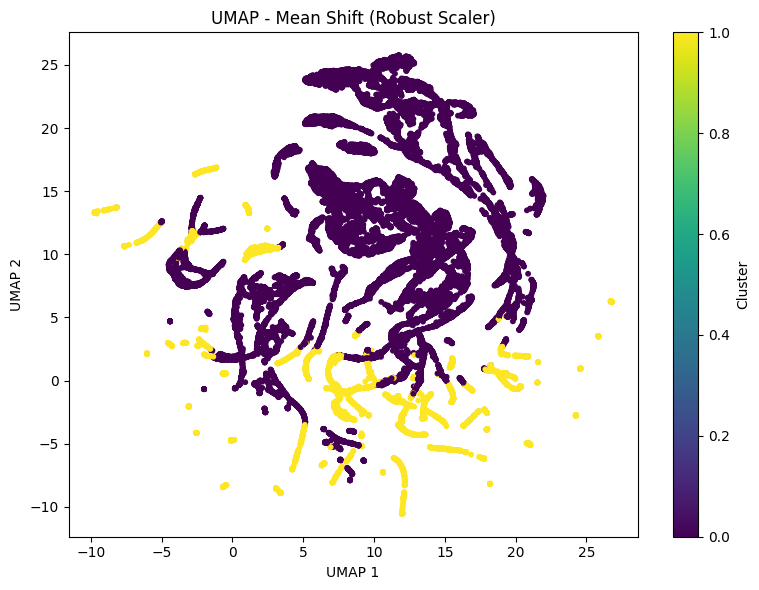

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [44]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_ms_rb, title="UMAP - Mean Shift (Robust Scaler)")

## 3.3 Hierarchical Clustering

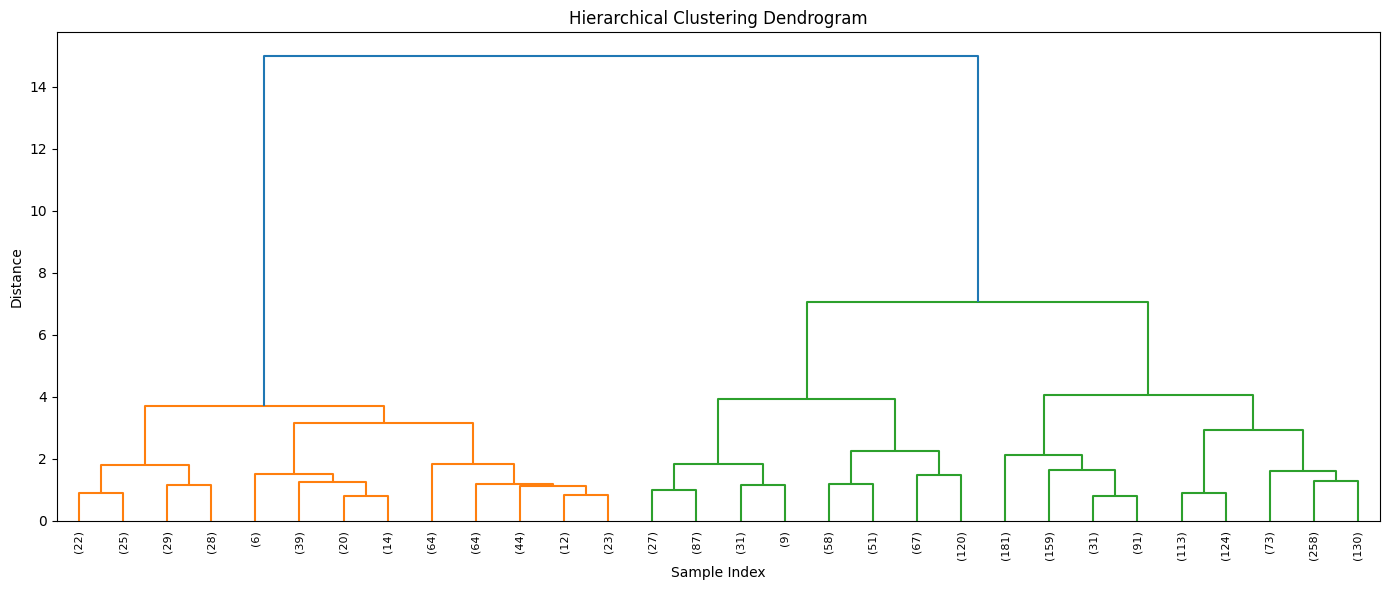

Silhouette Score: 0.2758
Cluster sizes:
0    10961
1     5256
2     5146
3     2388
4     9287
Name: count, dtype: int64


In [45]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_rb, labels_hierarchical_rb = fit_hierarchical(df_processed_rb, 5, method='ward')

/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


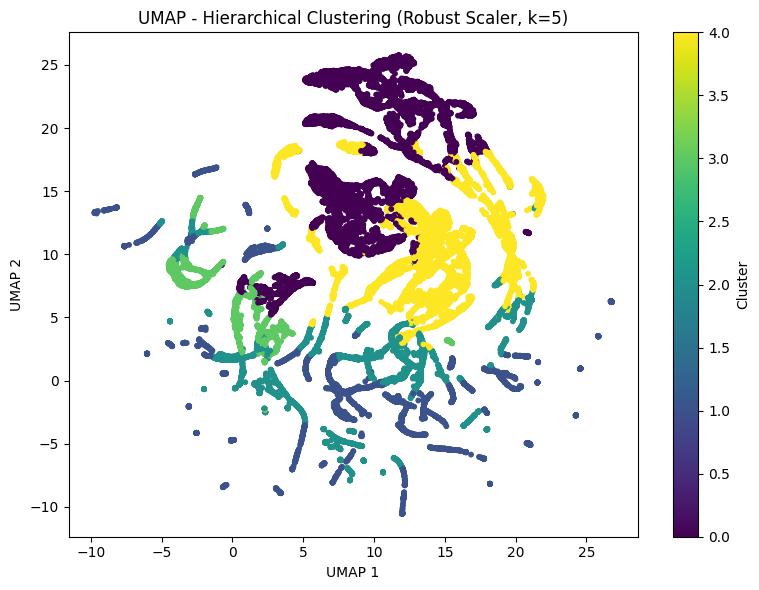

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [46]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_hierarchical_rb, title="UMAP - Hierarchical Clustering (Robust Scaler, k=5)")

## 3.4 DBSCAN

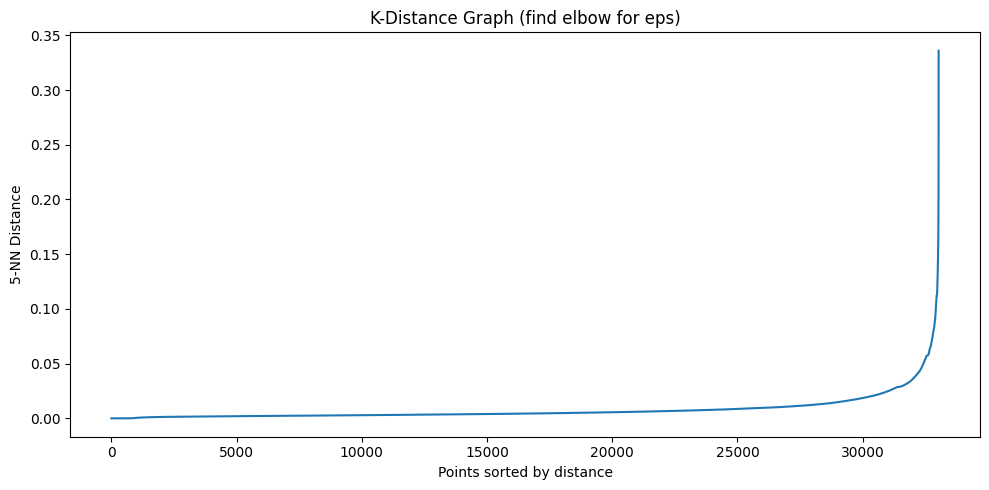

In [47]:
# Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_processed_rb, n_neighbors=5)

In [48]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_processed_rb, 2.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


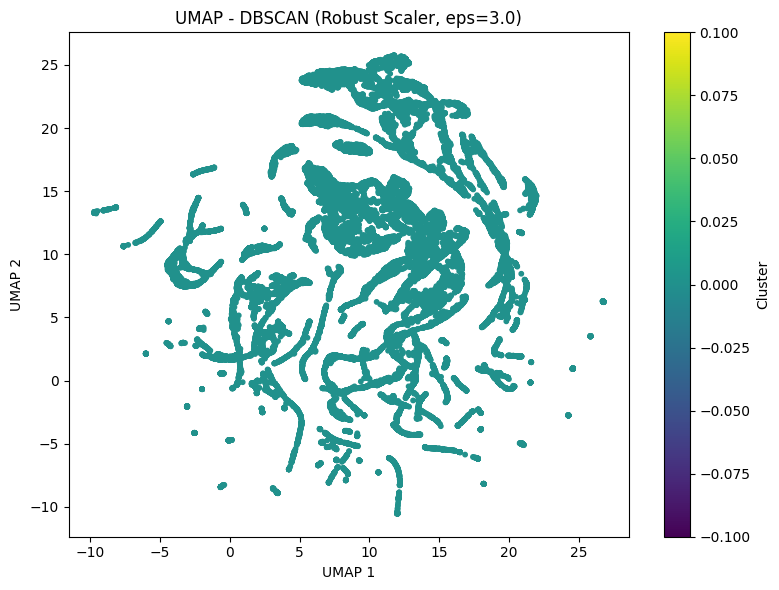

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [49]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_rb, labels_dbscan_rb = fit_dbscan(df_processed_rb, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_rb, labels_dbscan_rb, title="UMAP - DBSCAN (Robust Scaler, eps=3.0)")

In [50]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_processed_rb, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=3.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


## 3.5 Self-Organizing Map (SOM)

In [51]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_rb = fit_som(df_processed_rb, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

Trained SOM with map shape (10, 10) and 1000 iterations.
Unique BMU clusters: 100


In [52]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_rb = get_som_cluster_labels(som_result_rb['weights'], n_clusters=5, random_state=42)
print(neuron_labels_rb)

[[3 3 2 2 2 2 1 1 1 1]
 [3 3 3 2 2 2 1 1 1 1]
 [3 3 3 3 2 2 2 1 1 1]
 [3 3 3 3 4 2 2 2 1 1]
 [3 3 3 4 4 4 2 2 2 2]
 [0 0 0 0 4 4 4 2 2 2]
 [0 0 0 0 4 4 4 4 4 4]
 [0 0 0 0 0 0 4 4 4 4]
 [0 0 0 0 0 0 0 4 4 4]
 [0 0 0 0 0 0 0 4 4 4]]


In [ ]:
# Assign each data sample to a SOM neuron cluster label
labels_som_rb, neuron_labels_rb = assign_som_clusters(som_result_rb['weights'], df_processed_rb, n_clusters=5, random_state=42)
print((labels_som_rb, neuron_labels_rb))

(array([3, 0, 1, ..., 3, 4, 1], shape=(33038,), dtype=int32), array([[2, 2, 2, 2, 2, 3, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 3, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 3, 3, 0, 0, 0],
       [2, 2, 2, 2, 2, 3, 3, 3, 3, 3],
       [2, 2, 2, 2, 1, 1, 3, 3, 3, 3],
       [2, 2, 2, 1, 1, 1, 1, 3, 3, 3],
       [4, 4, 2, 1, 1, 1, 1, 1, 1, 1],
       [4, 4, 4, 1, 1, 1, 1, 1, 1, 1],
       [4, 4, 4, 1, 1, 1, 1, 1, 1, 1],
       [4, 4, 4, 1, 1, 1, 1, 1, 1, 1]], dtype=int32))


## 3.6 T-SNE

A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...
--- A gerar projeções t-SNE para comparação de modelos ---


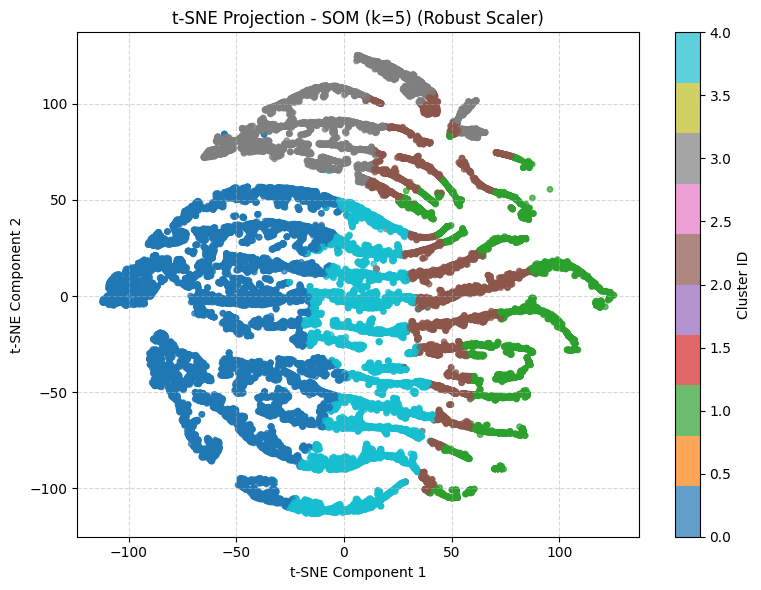

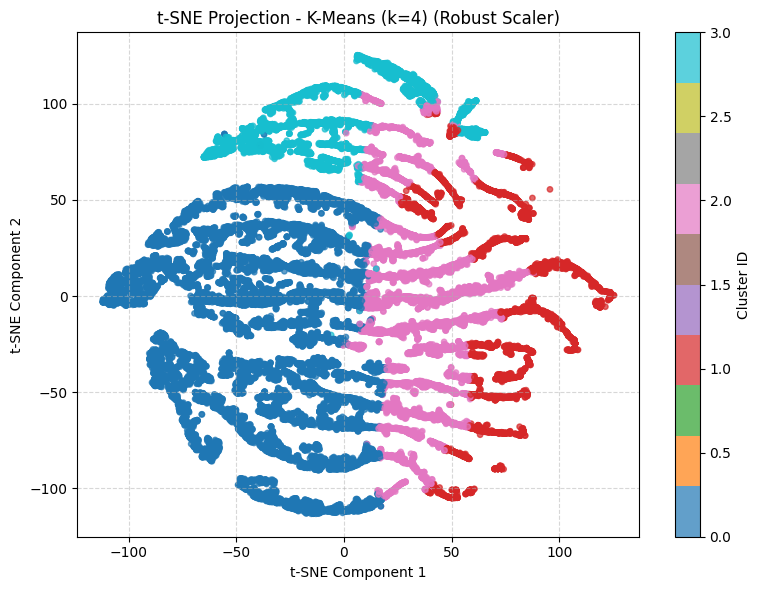

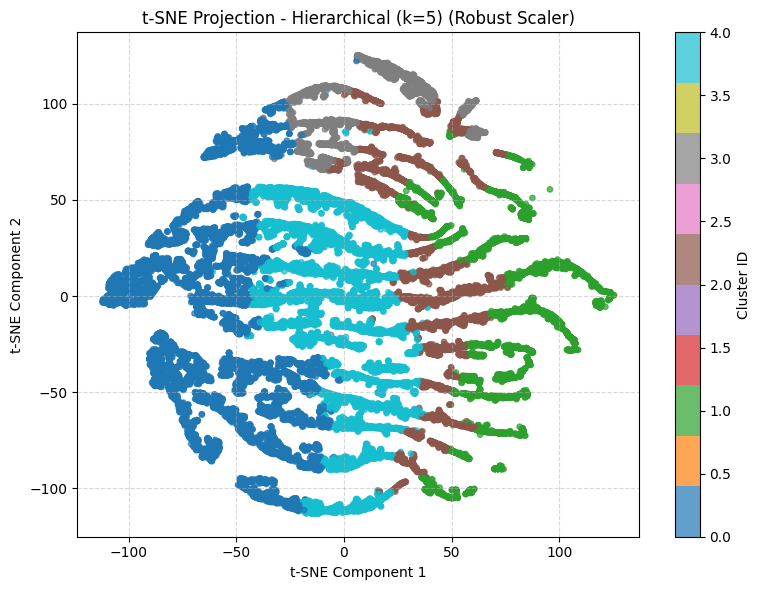

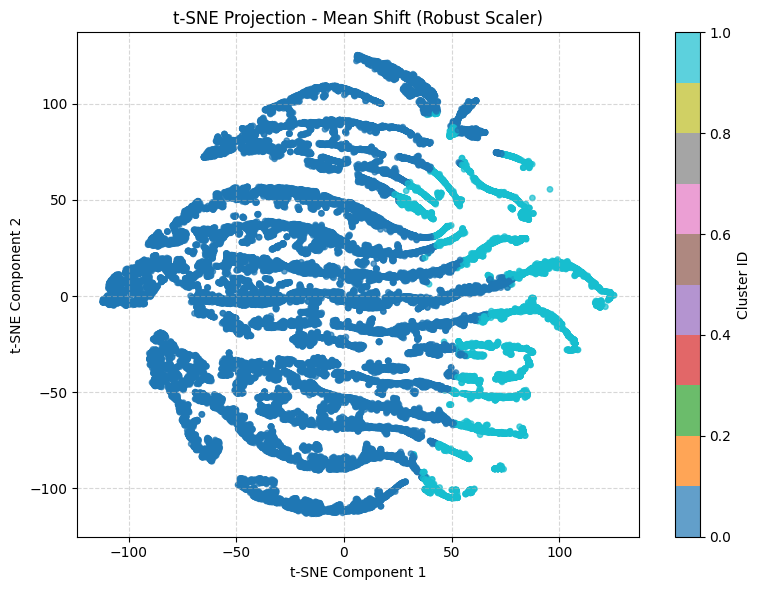

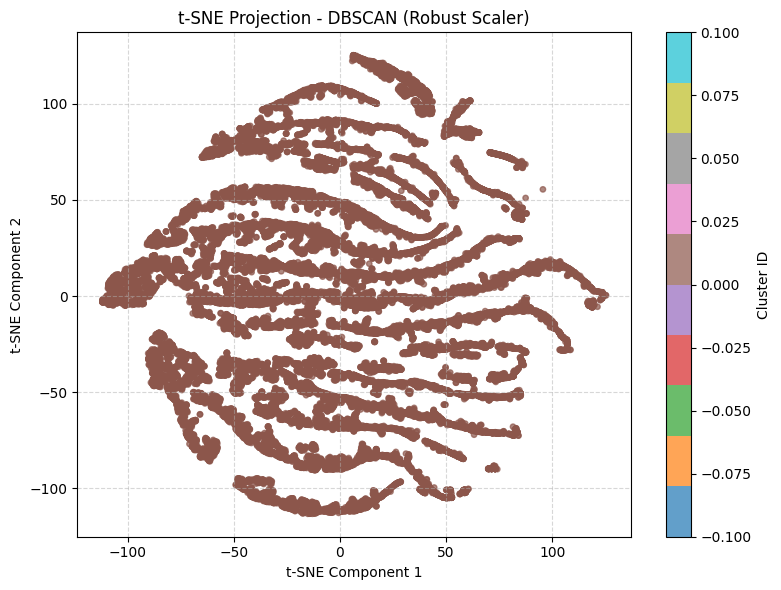

In [80]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. PASSO ÚNICO: Calcular as coordenadas t-SNE uma única vez para o teu dataset
# (Isto é o que demora tempo, por isso fazemos fora do loop)
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca', max_iter=1000)

print("A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...")
X_tsne = tsne.fit_transform(df_processed_rb)


# 2. DEFINIR O DICIONÁRIO: Junta aqui as variáveis de labels de todos os teus modelos
# Certifica-te de que já correstes as células que criam estas variáveis de labels!
labels_todos_modelos = {
    'SOM (k=5)': labels_som_rb,
    'K-Means (k=4)': labels_kmeans_rb,          # Descomenta se tiveres esta variável
    'Hierarchical (k=5)': labels_hierarchical_rb, # Descomenta se tiveres esta variável
    'Mean Shift': labels_ms_rb,
    'DBSCAN': labels_dbscan_rb                    # Descomenta se tiveres esta variável
}


# 3. O LOOP: Desenhar automaticamente um gráfico t-SNE para cada modelo
print("--- A gerar projeções t-SNE para comparação de modelos ---")

for nome_modelo, labels_modelo in labels_todos_modelos.items():
    
    plt.figure(figsize=(8, 6))
    
    # Criar o gráfico usando as mesmas coordenadas X_tsne, mas mudando as cores (c=labels_modelo)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_modelo, cmap='tab10', s=15, alpha=0.7)
    
    # Configurações estéticas do gráfico
    plt.colorbar(scatter, label='Cluster ID')
    plt.title(f"t-SNE Projection - {nome_modelo} (Robust Scaler)")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# 4. Clustering with MinMax Scaler

## 4.1 K-Means

k=2 | Inertia: 1391.93 | Silhouette: 0.5573
k=3 | Inertia: 1024.69 | Silhouette: 0.4031
k=4 | Inertia: 831.70 | Silhouette: 0.3953
k=5 | Inertia: 698.28 | Silhouette: 0.3364
k=6 | Inertia: 616.88 | Silhouette: 0.3403
k=7 | Inertia: 549.68 | Silhouette: 0.3383
k=8 | Inertia: 498.23 | Silhouette: 0.3418
k=9 | Inertia: 454.75 | Silhouette: 0.3320
k=10 | Inertia: 413.04 | Silhouette: 0.3451


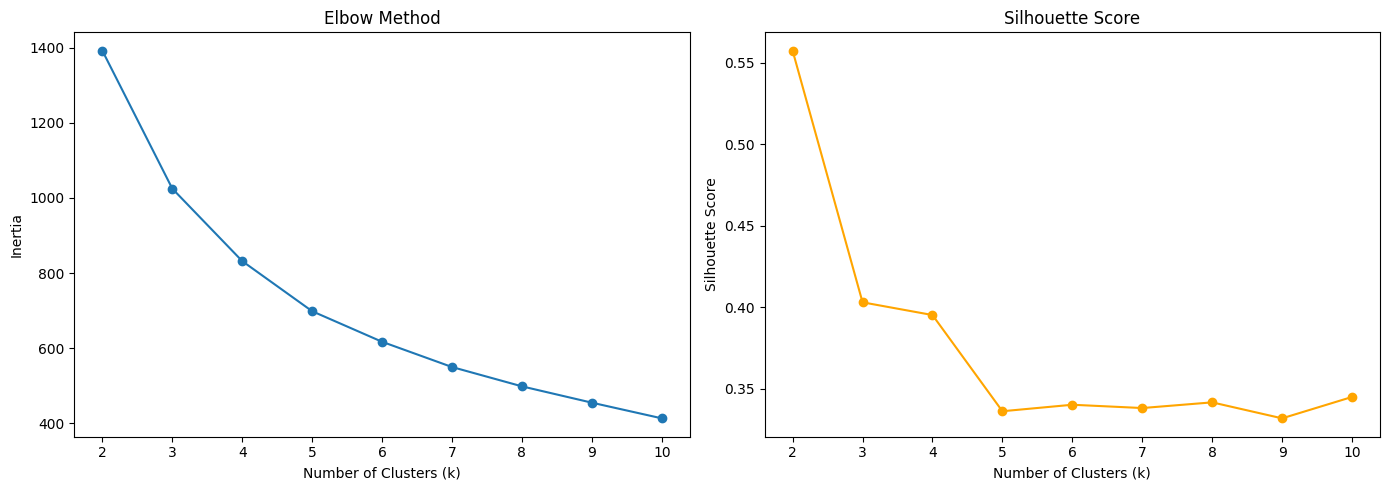

In [56]:
# Search for the optimal number of clusters (k) using Elbow & Silhouette methods
inertias, silhouette_scores = find_optimal_k(df_processed_mm)

In [57]:
# Fit the final K-Means model with the optimal k=4 clusters
kmeans_profile_mm = fit_kmeans(df_processed_mm, 4)
print(kmeans_profile_mm)

Silhouette Score: 0.3953
Cluster sizes:
0    16833
1     4887
2     7415
3     3903
Name: count, dtype: int64
                                         cluster_0  cluster_1  cluster_2  \
promo_hunter_score                        0.052136   0.362112   0.190377   
percentage_of_products_bought_promotion   0.167588   0.849495   0.473136   
total_lifetime_spend                      0.503976   0.498631   0.503703   
number_complaints                         0.077447   0.148476   0.135243   

                                         cluster_3  
promo_hunter_score                        0.065434  
percentage_of_products_bought_promotion   0.228508  
total_lifetime_spend                      0.506962  
number_complaints                         0.348750  


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


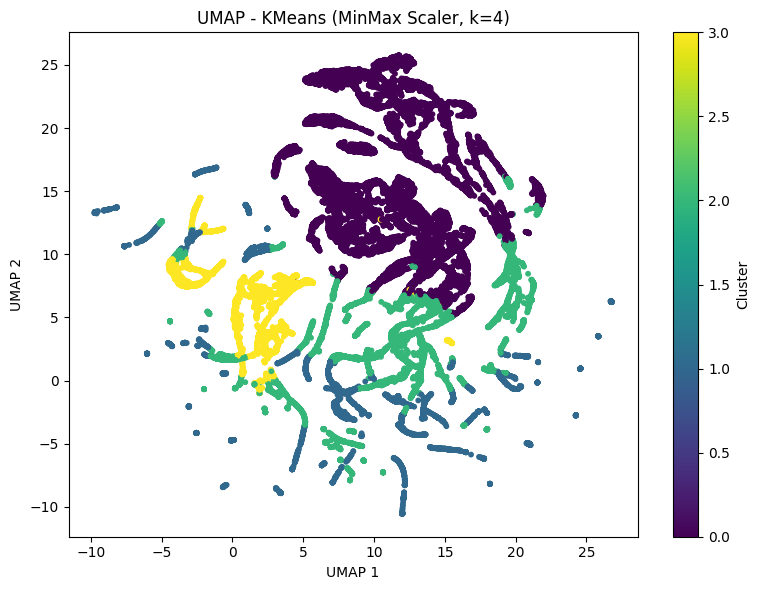

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [58]:
# Fit KMeans with optimal k=4 to get cluster labels for UMAP visualization
kmeans_opt_mm = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans_mm = kmeans_opt_mm.fit_predict(df_processed_mm)

# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_kmeans_mm, title="UMAP - KMeans (MinMax Scaler, k=4)")

## 4.2 Mean Shift

In [59]:
# Fit Mean Shift clustering to automatically determine the number of clusters
mean_shift_mm = MeanShift(bin_seeding=True)
labels_ms_mm = mean_shift_mm.fit_predict(df_processed_mm)
print("MinMax Scaler MeanShift cluster count:", len(np.unique(labels_ms_mm)))
if len(np.unique(labels_ms_mm)) > 1:
    print(f"MinMax Scaler MeanShift silhouette: {silhouette_score(df_processed_mm, labels_ms_mm):.4f}")
else:
    print("MinMax Scaler MeanShift silhouette: not defined (single cluster)")
print(pd.Series(labels_ms_mm).value_counts().sort_index())

MinMax Scaler MeanShift cluster count: 2
MinMax Scaler MeanShift silhouette: 0.5640
0    27224
1     5814
Name: count, dtype: int64


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


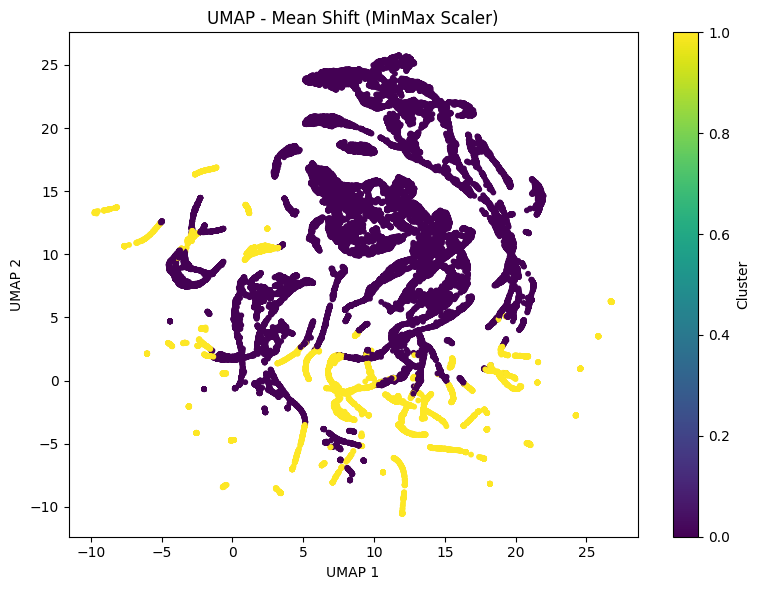

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [60]:
# Visualize Mean Shift cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_ms_mm, title="UMAP - Mean Shift (MinMax Scaler)")

## 4.3 Hierarchical Clustering

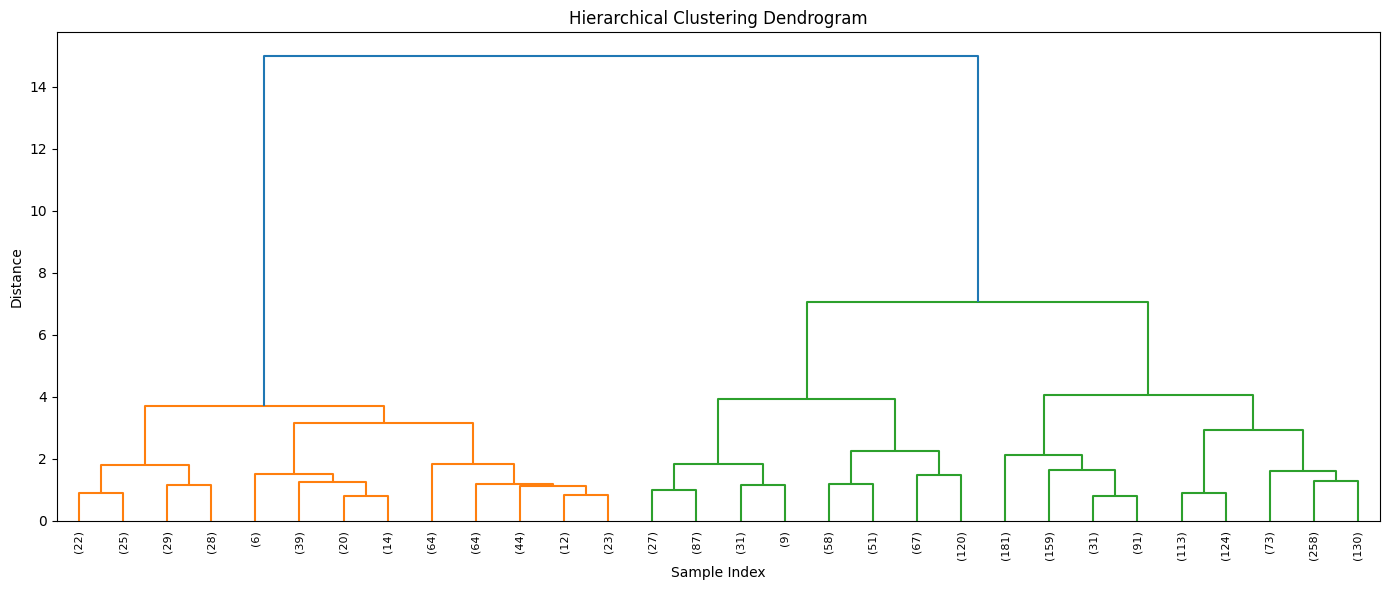

Silhouette Score: 0.2758
Cluster sizes:
0    10961
1     5256
2     5146
3     2388
4     9287
Name: count, dtype: int64


In [61]:
# Fit the Hierarchical Agglomerative Clustering model with 5 clusters (Ward's linkage)
hierarchical_model_mm, labels_hierarchical_mm = fit_hierarchical(df_processed_mm, 5, method='ward')

/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


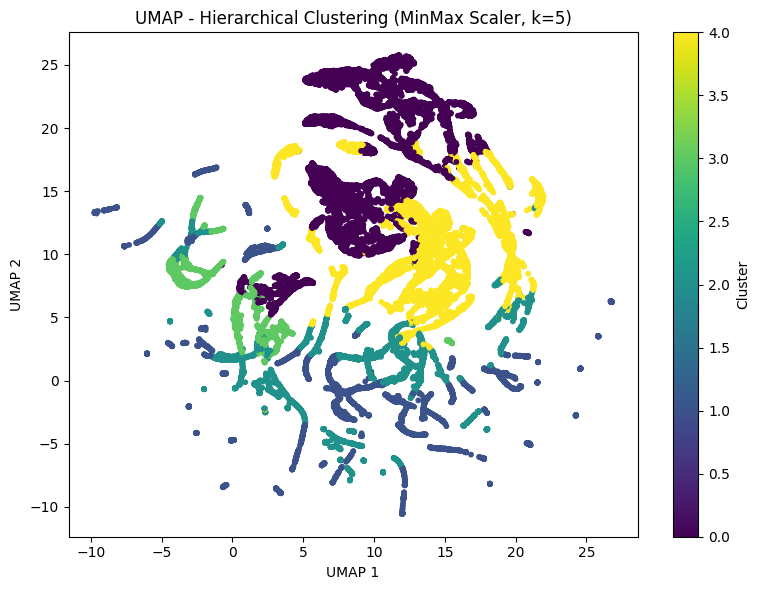

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [62]:
# Visualize Hierarchical Clustering cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_hierarchical_mm, title="UMAP - Hierarchical Clustering (MinMax Scaler, k=5)")

## 4.4 DBSCAN

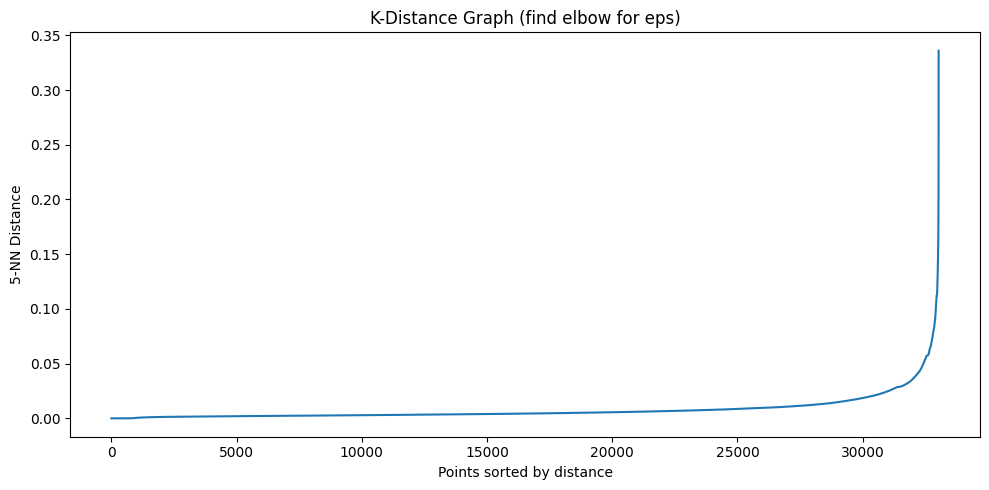

In [63]:
# Generate a K-Distance graph to determine the optimal epsilon (eps) value for DBSCAN
find_optimal_eps(df_processed_mm, n_neighbors=5)

In [64]:
# Fit DBSCAN clustering using epsilon=2.5 to evaluate cluster formation
print(fit_dbscan(df_processed_mm, 2.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=2.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


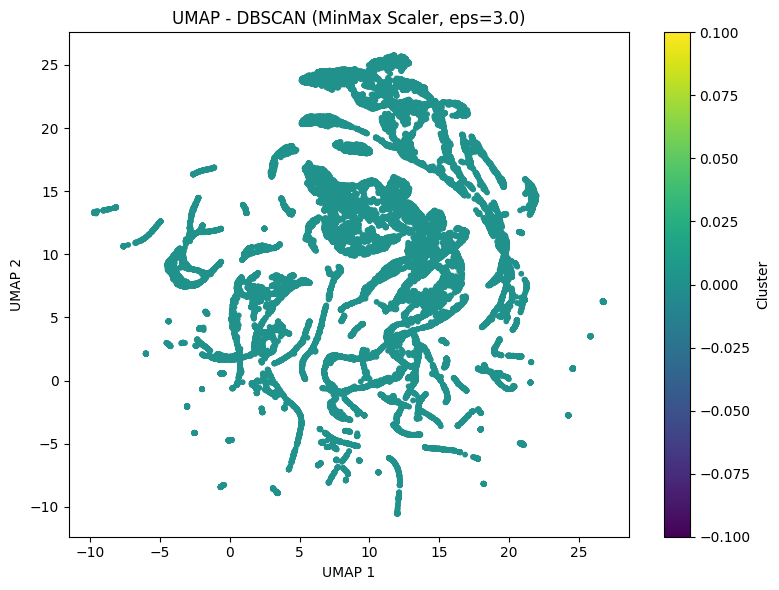

array([[12.747199 , -1.0436101],
       [ 6.4732194, 20.271656 ],
       [ 6.781936 , 12.776484 ],
       ...,
       [15.497542 , 18.202797 ],
       [ 0.9426239, 13.899585 ],
       [12.819566 ,  9.675927 ]], shape=(33038, 2), dtype=float32)

In [65]:
# Fit DBSCAN clustering using epsilon=3.0 and min_samples=5
dbscan_model_mm, labels_dbscan_mm = fit_dbscan(df_processed_mm, 3.0, min_samples=5)

# Visualize DBSCAN (eps=3.0) cluster assignments using UMAP dimensionality reduction
plot_umap(df_processed_mm, labels_dbscan_mm, title="UMAP - DBSCAN (MinMax Scaler, eps=3.0)")

In [66]:
# Fit DBSCAN clustering using epsilon=3.5 to evaluate cluster formation
print(fit_dbscan(df_processed_mm, 3.5, min_samples=5))

Number of clusters: 1
Noise points: 0 (0.00%)
Cluster sizes:
0    33038
Name: count, dtype: int64
(DBSCAN(eps=3.5), array([0, 0, 0, ..., 0, 0, 0], shape=(33038,)))


## 4.5 Self-Organizing Map (SOM)

In [67]:
# Fit the Self-Organizing Map (SOM) to the dataset
som_result_mm = fit_som(df_processed_mm, map_shape=(10, 10), n_iterations=1000, learning_rate=0.5, random_state=42, plot_u_matrix=False)

Trained SOM with map shape (10, 10) and 1000 iterations.
Unique BMU clusters: 100


In [68]:
# Cluster the trained SOM neurons and assign each sample to its respective neuron cluster
neuron_labels_mm = get_som_cluster_labels(som_result_mm['weights'], n_clusters=5, random_state=42)
print(neuron_labels_mm)

[[3 3 2 2 2 2 1 1 1 1]
 [3 3 3 2 2 2 1 1 1 1]
 [3 3 3 3 2 2 2 1 1 1]
 [3 3 3 3 4 2 2 2 1 1]
 [3 3 3 4 4 4 2 2 2 2]
 [0 0 0 0 4 4 4 2 2 2]
 [0 0 0 0 4 4 4 4 4 4]
 [0 0 0 0 0 0 4 4 4 4]
 [0 0 0 0 0 0 0 4 4 4]
 [0 0 0 0 0 0 0 4 4 4]]


In [69]:
# Assign each data sample to a SOM neuron cluster label
labels_som_mm, neuron_labels_mm = assign_som_clusters(som_result_mm['weights'], df_processed_mm, n_clusters=5, random_state=42)
print((labels_som_mm, neuron_labels_mm))

(array([2, 0, 0, ..., 0, 1, 0], shape=(33038,), dtype=int32), array([[3, 3, 2, 2, 2, 2, 1, 1, 1, 1],
       [3, 3, 3, 2, 2, 2, 1, 1, 1, 1],
       [3, 3, 3, 3, 2, 2, 2, 1, 1, 1],
       [3, 3, 3, 3, 4, 2, 2, 2, 1, 1],
       [3, 3, 3, 4, 4, 4, 2, 2, 2, 2],
       [0, 0, 0, 0, 4, 4, 4, 2, 2, 2],
       [0, 0, 0, 0, 4, 4, 4, 4, 4, 4],
       [0, 0, 0, 0, 0, 0, 4, 4, 4, 4],
       [0, 0, 0, 0, 0, 0, 0, 4, 4, 4],
       [0, 0, 0, 0, 0, 0, 0, 4, 4, 4]], dtype=int32))


## 4.6 T-SNE

A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...
--- A gerar projeções t-SNE para comparação de modelos ---


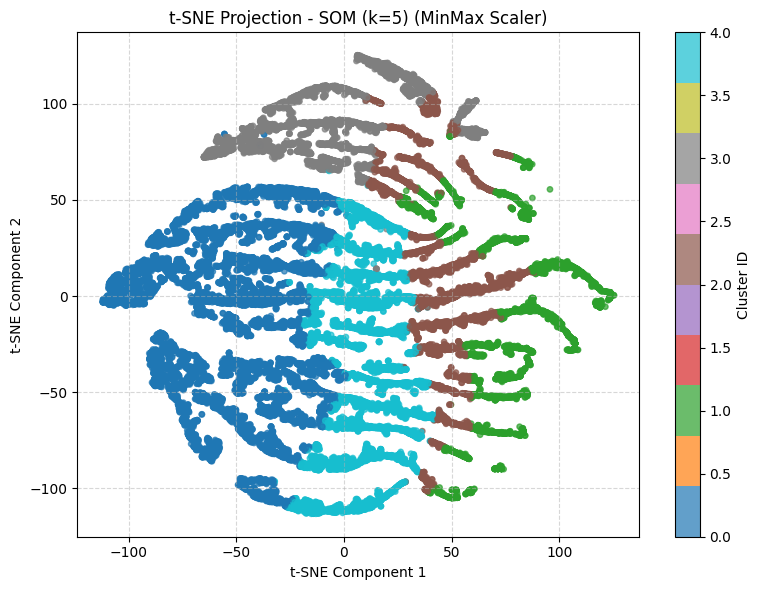

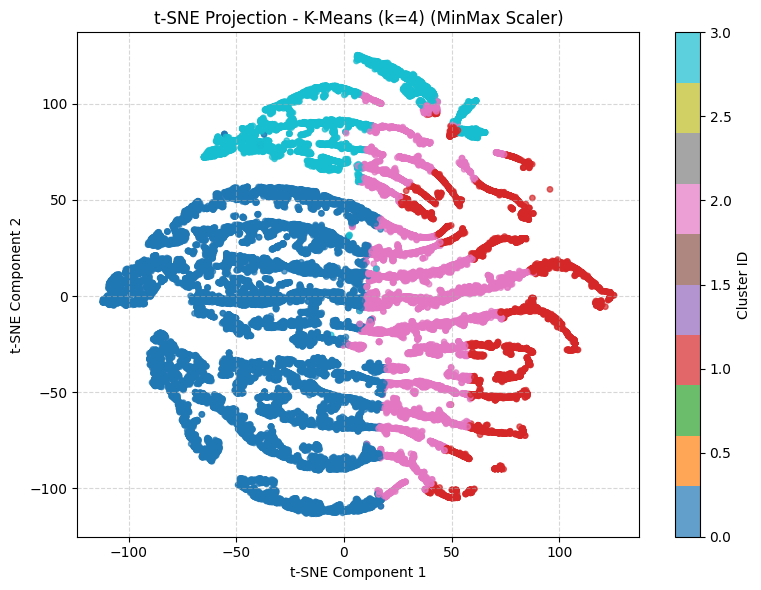

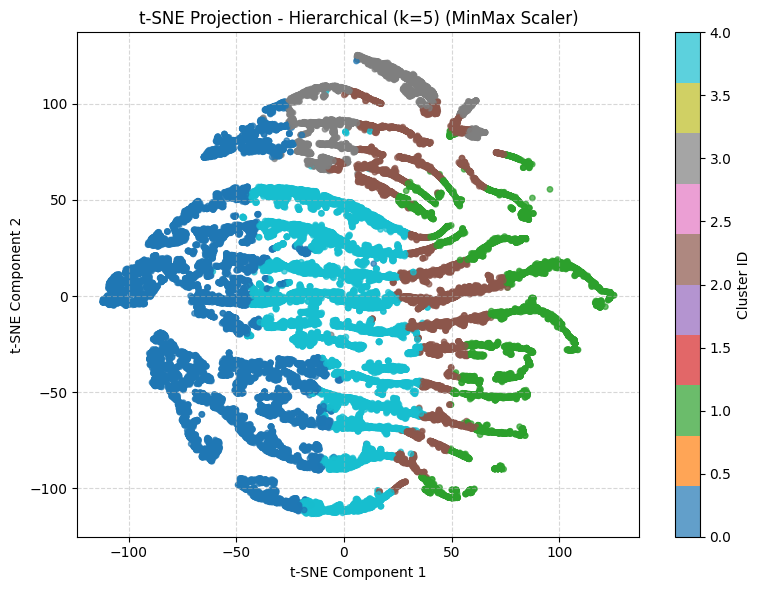

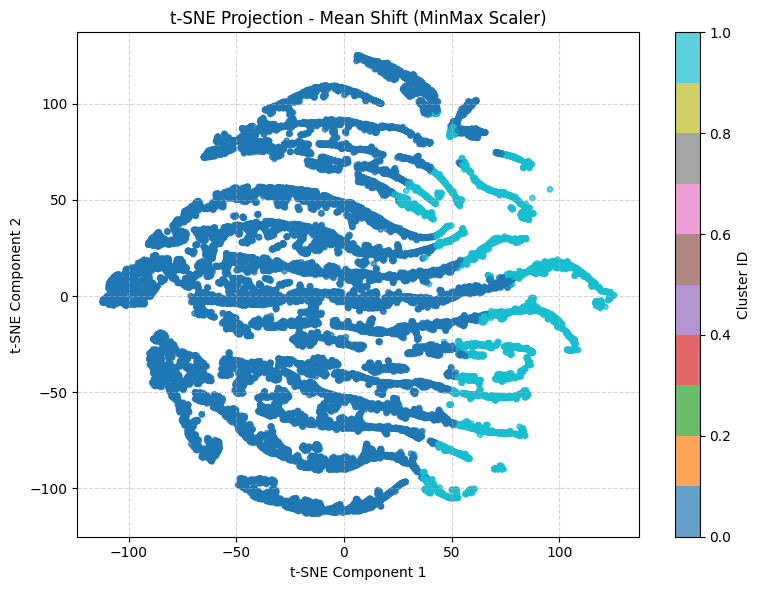

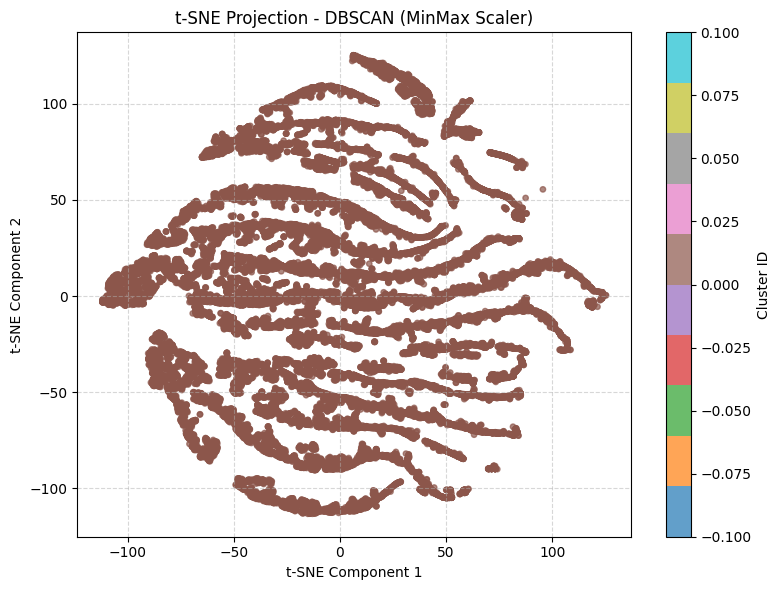

In [79]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. PASSO ÚNICO: Calcular as coordenadas t-SNE uma única vez para o teu dataset
# (Isto é o que demora tempo, por isso fazemos fora do loop)
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca', max_iter=1000)

print("A calcular as coordenadas t-SNE globais (isto pode demorar uns segundos)...")
X_tsne = tsne.fit_transform(df_processed_mm)


# 2. DEFINIR O DICIONÁRIO: Junta aqui as variáveis de labels de todos os teus modelos
# Certifica-te de que já correstes as células que criam estas variáveis de labels!
labels_todos_modelos = {
    'SOM (k=5)': labels_som_mm,
    'K-Means (k=4)': labels_kmeans_mm,          # Descomenta se tiveres esta variável
    'Hierarchical (k=5)': labels_hierarchical_mm, # Descomenta se tiveres esta variável
    'Mean Shift': labels_ms_mm,
    'DBSCAN': labels_dbscan_mm                    # Descomenta se tiveres esta variável
}


# 3. O LOOP: Desenhar automaticamente um gráfico t-SNE para cada modelo
print("--- A gerar projeções t-SNE para comparação de modelos ---")

for nome_modelo, labels_modelo in labels_todos_modelos.items():
    
    plt.figure(figsize=(8, 6))
    
    # Criar o gráfico usando as mesmas coordenadas X_tsne, mas mudando as cores (c=labels_modelo)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_modelo, cmap='tab10', s=15, alpha=0.7)
    
    # Configurações estéticas do gráfico
    plt.colorbar(scatter, label='Cluster ID')
    plt.title(f"t-SNE Projection - {nome_modelo} (MinMax Scaler)")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# 5. Model Comparison

In [71]:
import importlib
import Clustering
importlib.reload(Clustering)
from Clustering import compare_models, plot_tsne

# Compare all fitted models using their Silhouette Scores to find the best configuration
labels_dict_st = {
    'KMeans (k=4)': labels_kmeans_st,
    'Hierarchical (k=5)': labels_hierarchical_st,
    'DBSCAN (eps=3.0)': labels_dbscan_st,
    'MeanShift': labels_ms_st,
    'SOM (k=5)': labels_som_st
}
print("--- Standard Scaler Comparison ---")
compare_models(df_processed_st, labels_dict_st)

# Compare all fitted models for Robust Scaler
labels_dict_rb = {
    'KMeans (k=4)': labels_kmeans_rb,
    'Hierarchical (k=5)': labels_hierarchical_rb,
    'DBSCAN (eps=3.0)': labels_dbscan_rb,
    'MeanShift': labels_ms_rb,
    'SOM (k=5)': labels_som_rb
}
print("\n--- Robust Scaler Comparison ---")
compare_models(df_processed_rb, labels_dict_rb)

# Compare all fitted models for MinMax Scaler
labels_dict_mm = {
    'KMeans (k=4)': labels_kmeans_mm,
    'Hierarchical (k=5)': labels_hierarchical_mm,
    'DBSCAN (eps=3.0)': labels_dbscan_mm,
    'MeanShift': labels_ms_mm,
    'SOM (k=5)': labels_som_mm
}
print("\n--- MinMax Scaler Comparison ---")
compare_models(df_processed_mm, labels_dict_mm)

--- Standard Scaler Comparison ---

--- Model Comparison (Silhouette Scores) ---
KMeans (k=4): 0.3953
Hierarchical (k=5): 0.2758
DBSCAN (eps=3.0): Silhouette score not applicable (insufficient clusters or only noise).
MeanShift: 0.5640
SOM (k=5): 0.3251

Best model: MeanShift with silhouette score 0.5640

--- Robust Scaler Comparison ---

--- Model Comparison (Silhouette Scores) ---
KMeans (k=4): 0.3953
Hierarchical (k=5): 0.2758
DBSCAN (eps=3.0): Silhouette score not applicable (insufficient clusters or only noise).
MeanShift: 0.5640
SOM (k=5): 0.3251

Best model: MeanShift with silhouette score 0.5640

--- MinMax Scaler Comparison ---

--- Model Comparison (Silhouette Scores) ---
KMeans (k=4): 0.3953
Hierarchical (k=5): 0.2758
DBSCAN (eps=3.0): Silhouette score not applicable (insufficient clusters or only noise).
MeanShift: 0.5640
SOM (k=5): 0.3251

Best model: MeanShift with silhouette score 0.5640


{'KMeans (k=4)': 0.3953039254718227,
 'Hierarchical (k=5)': 0.27575623195801746,
 'DBSCAN (eps=3.0)': nan,
 'MeanShift': 0.5639644806369516,
 'SOM (k=5)': 0.3251103345541835}